<br/>

<div align="center">
<span style="font-size: 2.5em;">Neural vs Analytical Posterior</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Total-event-count likelihood (no spectral info)</span>
</div>

We compare analytical Poisson posteriors with neural-network posteriors when the data are reduced to a single number: the total event count. This removes spectral information and introduces degeneracies in $(m_\chi, c_p)$, making it a useful stress test for calibration and bias.

In [ ]:
import os
desired_root_name = "xenon-sbi" 
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch

from data.mc_generator import mc_generator
from analytical.ppg_class import PoissonPosteriorGrid
from configs.config import MCConfig, load_model
from utils.posteriors import plot_posterior_single, plot_posteriors_comparison, posterior_grid
from utils.processing import preprocess_features, make_dataloaders, make_negative_pairs

In [3]:
# --------------------- SELECT MODEL TO LOAD ---------------------

modelname = "ntot"          
halo      = "default"       
datatag   = "low"
n_train   = 300_000

bins = MCConfig().bins     
top_k     = 10     

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------- PATHS ---------------------

DATAPATH = f"data/datasets/wimpy/{halo}/wimpy_n{n_train}_{datatag}_{halo}.pt"
MODELPATH = f"models/wimpy/{halo}/{modelname}_n{n_train}_{datatag}_{halo}.pt"
print(f"Loading model from:\n{MODELPATH}\n")

# --------------------- LOAD MODEL ---------------------
model, _ = load_model(MODELPATH, modelname, bins, top_k, device, print_arch=True)

Loading model from:
models/wimpy/default/ntot_n300000_low_default.pt

Ntot_MLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.05, inplace=False)
    (12): Linear(in_features=64, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): SiLU()
    (15): Dropout(p=0.05, inplace=False)
    (16): Linear(in_features=64, out_features=1, bias=True)
    (17): Sigm

In [ ]:
# ------------- LOAD DATA ----------------

data = torch.load(DATAPATH, weights_only=False)

theta_tensor = data["theta"]
feature_tensor = data["features"]
logm_range  = data['logm_range']
logcp_range = data['logcp_range']
mc_cfg      = MCConfig()

feature_tensor = preprocess_features(model, feature_tensor, device)
X_all, T_all, Y_all = make_negative_pairs(feature_tensor, theta_tensor)

_, val_loader, _ = make_dataloaders(X_all, T_all, Y_all)

<br/>

<div align="center">
<span style="font-size: 1.5em;"> Analytical Posterior (Total Count) </span>

</div>

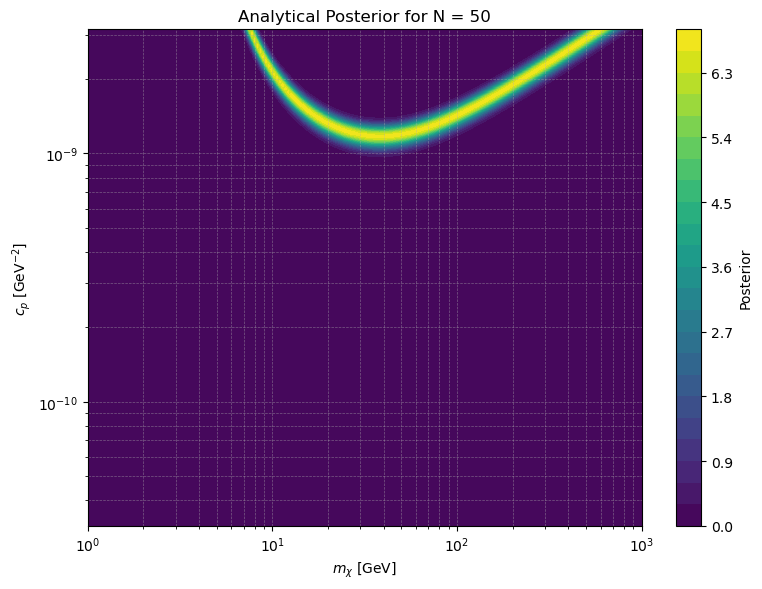

In [ ]:
# --------------------- POSTERIOR — NEVENTS ---------------------

ppg = PoissonPosteriorGrid.load_or_compute("low", 200, mc_generator)
n_observed = 50
ppg.plot_posterior_nevents(n_observed, levels=25)

<br/>

<div align="center">
<span style="font-size: 1.5em;"> Neural Network Posterior </span>

</div>

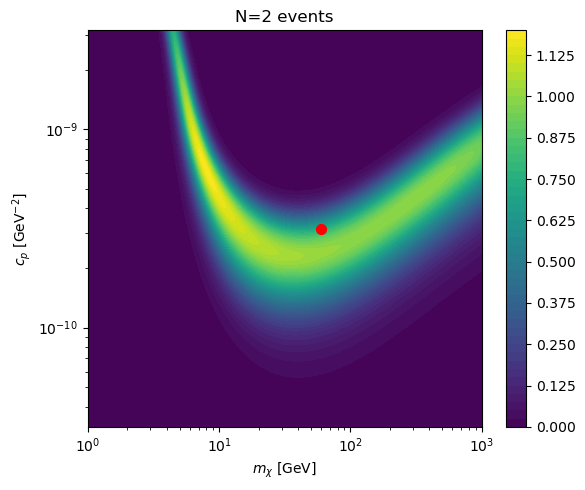

In [ ]:
# --------------------- POSTERIOR — SINGLE POINT --------------------- 

mchi = 60.0
cp = 10**(-9.5)

plot_posterior_single(
    model,
    mchi=mchi,
    cp=cp,
    mc_config=mc_cfg,
    top_k=top_k,
    device=device,
)

<br/>

<div align="center">
<span style="font-size: 1.5em;"> Comparison: NN vs Analytical </span>

</div>

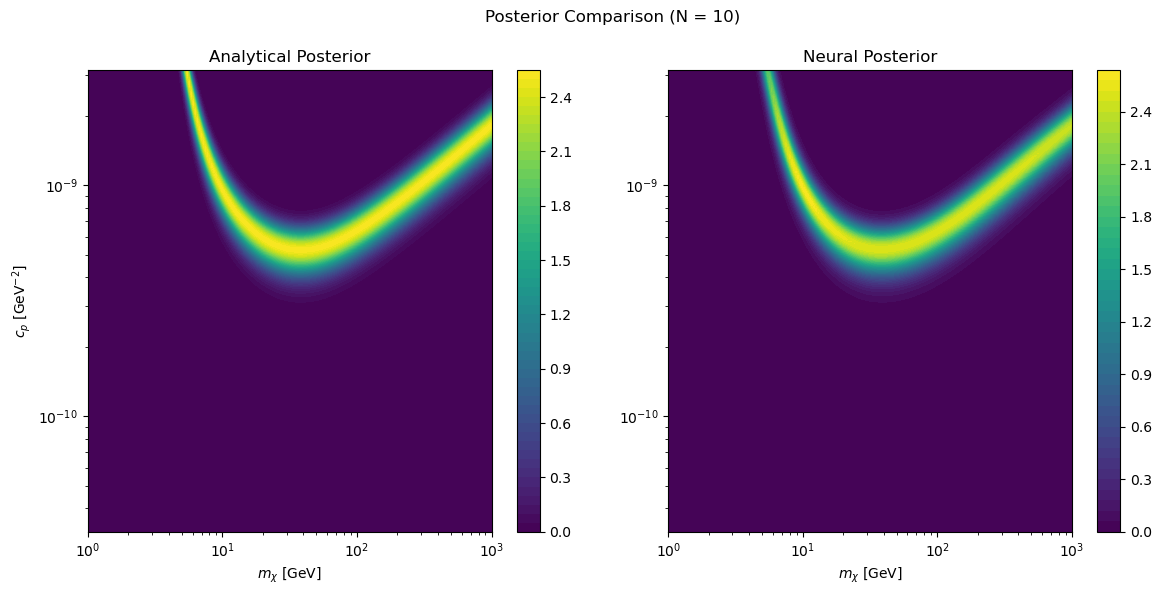

In [ ]:
# --------------------- COMPARISON NN vs ANALYTICAL ---------------------

n_obs = 10

# Convert event count to model input (as used during training)
x = torch.tensor([n_obs], dtype=torch.float32).to(device)
x = torch.log10(x + 1)     

# Compute NN posterior on (log mχ, log cp)
posterior_nn, lm_nn, lc_nn = posterior_grid(
    x, logm_range, logcp_range, 200, model, device
)
m_nn, cp_nn = 10**lm_nn, 10**lc_nn

# Analytical benchmark posterior
ppg = PoissonPosteriorGrid.load_or_compute("low", 200, mc_generator)
posterior_analytical = ppg.posterior_nevents(n_obs)
m_an, cp_an = 10**ppg.logm_vals, 10**ppg.logcp_vals

plot_posteriors_comparison(
    None, None,                      
    posterior_analytical, m_an, cp_an,
    posterior_nn, m_nn, cp_nn,
    n_obs                            
)